# **Práctica Deep Learning – Predicción de Engagement en POIs Turísticos**
*KeepCoding – Junio 2025*

Este cuaderno implementa de forma **completa y reproducible** el flujo de trabajo solicitado en la práctica:

1. Preparación y análisis de datos
2. Diseño de modelo multimodal (imágenes + metadatos)
3. Entrenamiento y optimización
4. Evaluación, interpretación y guardado del modelo



In [2]:

# Sólo descomenta y ejecuta si estés en Colab.
from google.colab import drive
import os

drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Deep Learning/Practica_Deep_Learning'
os.chdir(project_path)
print("Montado Google Drive y cambiado al directorio del proyecto.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Montado Google Drive y cambiado al directorio del proyecto.


In [61]:
!pip install -r requirements.txt

#Importación de librerías y scripts
import ast
import cv2
import torch
import optuna
import folium
import random
import numpy as np
import pandas as pd
import seaborn as sns
import optuna.visualization
import pickle
import copy
import matplotlib.pyplot as plt
from math import ceil
from tensorboard import program
from torchvision import transforms
from torchvision import models
from torch import nn, optim
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import MultiLabelBinarizer
from tqdm import tqdm
from pathlib import Path
from PIL import Image, UnidentifiedImageError, ImageFile
from collections import Counter
from IPython.display import display
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from src.module_utils import *

In [4]:
# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Usando dispositivo:', device)

Usando dispositivo: cuda


In [5]:
# Carpeta para guardar modelos
MODELS_DIR = Path("Models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## **1. Preparación y Análisis de los Datos**


### 1.1 Carga de los datos

In [6]:
# Cargar el dataset
df = pd.read_csv("Data/poi_dataset.csv")

# Mostrar las primeras filas del dataset
df.head()

,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
0,4b36a3ed-3b28-4bc7-b975-1d48b586db03,Galería Fran Reus,La Galería Fran Reus es un espacio dedicado a ...,"['Escultura', 'Pintura']",1,2.642262,39.572694,[],500,10009,422,3582,78,data_main/4b36a3ed-3b28-4bc7-b975-1d48b586db03...
1,e32b3603-a94f-49df-8b31-92445a86377c,Convento de San Plácido,"El Convento de San Plácido en Madrid, fundado ...","['Patrimonio', 'Historia']",1,-3.704467,40.423037,[],500,10010,7743,96,2786,data_main/e32b3603-a94f-49df-8b31-92445a86377c...
2,0123a69b-13ac-4b65-a5d5-71a95560cff5,Instituto Geológico y Minero de España,"El Instituto Geológico y Minero de España, sit...","['Ciencia', 'Patrimonio']",2,-3.699694,40.442045,[],250,10015,3154,874,595,data_main/0123a69b-13ac-4b65-a5d5-71a95560cff5...
3,390d7d9e-e972-451c-b5e4-f494af15e788,Margarita Gil Roësset,"Margarita Gil Roësset, escultora y poetisa esp...",['Cultura'],1,-3.691228,40.427256,[],500,10011,8559,79,2358,data_main/390d7d9e-e972-451c-b5e4-f494af15e788...
4,023fc1bf-a1cd-4b9f-af78-48792ab1a294,Museo del Traje. Centro de Investigación del P...,"El Museo del Traje de Madrid, fundado en 2004,...","['Patrimonio', 'Cultura']",1,-3.727822,40.439665,[],500,10020,915,2896,143,data_main/023fc1bf-a1cd-4b9f-af78-48792ab1a294...


### 1.2 Análisis exploratorio

In [7]:
# Tamaño del dataset
print(f"Dimensiones del dataset: {df.shape}")

# Información general del dataset
print(f"Información general del dataset:")
df.info()

Dimensiones del dataset: (1569, 14)
Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1569 entries, 0 to 1568
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1569 non-null   object 
 1   name              1569 non-null   object 
 2   shortDescription  1569 non-null   object 
 3   categories        1569 non-null   object 
 4   tier              1569 non-null   int64  
 5   locationLon       1569 non-null   float64
 6   locationLat       1569 non-null   float64
 7   tags              1569 non-null   object 
 8   xps               1569 non-null   int64  
 9   Visits            1569 non-null   int64  
 10  Likes             1569 non-null   int64  
 11  Dislikes          1569 non-null   int64  
 12  Bookmarks         1569 non-null   int64  
 13  main_image_path   1569 non-null   object 
dtypes: float64(2), int64(6), object(6)
memory usage: 171.7+ KB


In [8]:
# Eliminamos las columnas: id, name, shortDescription
df.drop(columns=['id', 'name', 'shortDescription'], inplace=True)
df.columns

Index(['categories', 'tier', 'locationLon', 'locationLat', 'tags', 'xps',
       'Visits', 'Likes', 'Dislikes', 'Bookmarks', 'main_image_path'],
      dtype='object')

In [9]:
# Estadística descriptiva de las variables numéricas
print("\nEstadística descriptiva de todas las variables numéricas:")
print(df.describe())


Estadística descriptiva de todas las variables numéricas:
              tier  locationLon  locationLat          xps        Visits  \
count  1569.000000  1569.000000  1569.000000  1569.000000   1569.000000   
mean      1.541109    -1.132337    39.900141   750.382409  10011.943276   
std       0.637677    22.733401     9.662134   228.319854      5.456808   
min       1.000000  -121.951049   -62.940930     0.000000  10001.000000   
25%       1.000000    -3.725292    40.411754   600.000000  10008.000000   
50%       1.000000    -3.699140    40.421738   700.000000  10011.000000   
75%       2.000000    -3.673348    40.472458  1000.000000  10015.000000   
max       4.000000   158.333118    65.706572  1000.000000  10038.000000   

              Likes      Dislikes    Bookmarks  
count   1569.000000   1569.000000  1569.000000  
mean    3623.908222   2526.305927   973.261950  
std     4817.879374   2225.543360  1453.333948  
min      100.000000     52.000000    50.000000  
25%      464.000000 

### Análisis de variables categóricas

In [10]:
df["categories"][0]

"['Escultura', 'Pintura']"

In [11]:
type(df["categories"][0])

str

In [12]:
type(df["tags"][0])

str

In [13]:
# Convertir strings con formato de lista a listas reales
df["categories"] = df["categories"].apply(ast.literal_eval)
df["tags"] = df["tags"].apply(ast.literal_eval)

print(type(df["categories"][0]))
print(type(df["tags"][0]))

<class 'list'>
<class 'list'>


In [14]:
# Aplanamos y contamos valores únicos de 'categories'
num_unique_cat = df['categories'].explode().nunique()
print(f"Número de categorías únicas: {num_unique_cat}")

Número de categorías únicas: 12


categories
0       2
1      63
2     106
3    1073
4     325
Name: count, dtype: int64


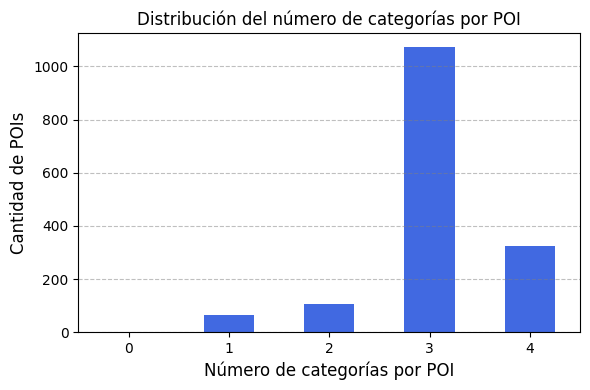

In [15]:
# Contar el número de categorías por POI
num_categories = df['categories'].apply(len)
print(num_categories.value_counts().sort_index())

# Historama
plt.figure(figsize=(6, 4))
num_categories.value_counts().sort_index().plot(kind='bar', color='#4169E1')
plt.xlabel('Número de categorías por POI', fontsize=12)
plt.ylabel('Cantidad de POIs', fontsize=12)
plt.title('Distribución del número de categorías por POI')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.5, linestyle='--', color='gray')
plt.tight_layout()
plt.show()

In [16]:
# Aplanamos y contamos valores únicos de 'tags'
num_unique_tag = df['tags'].explode().nunique()
print(f"Número de etiquetas únicas: {num_unique_tag}")

Número de etiquetas únicas: 2935


tags
0     107
1     136
2      24
3      56
4     102
5      58
6      33
7      10
8       8
9       2
10    473
11      6
12     88
13    466
Name: count, dtype: int64


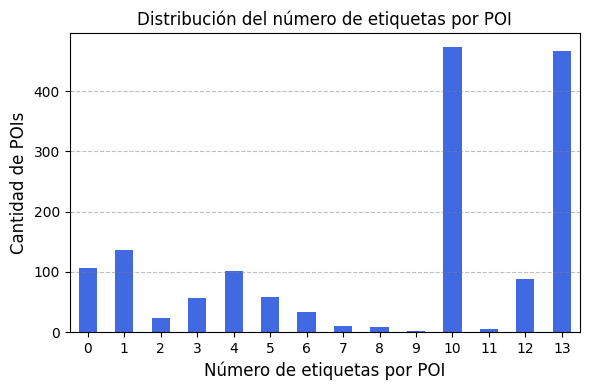

In [17]:
# Contar el número de 'tags' por POI
num_tag = df['tags'].apply(len)
print(num_tag.value_counts().sort_index())

# Historama
plt.figure(figsize=(6, 4))
num_tag.value_counts().sort_index().plot(kind='bar', color='#4169E1')
plt.xlabel('Número de etiquetas por POI', fontsize=12)
plt.ylabel('Cantidad de POIs', fontsize=12)
plt.title('Distribución del número de etiquetas por POI')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.5, linestyle='--', color='gray')
plt.tight_layout()
plt.show()

In [18]:
# Contar la frecuencia de cada tag
tag_freq = df['tags'].explode().value_counts()

# Top 10 más frecuentes
top10_tags = tag_freq.head(10).index.tolist()
print("Top 10 tags más frecuentes:", top10_tags)
print(tag_freq.head(10))

Top 10 tags más frecuentes: ['Historia', 'Madrid', 'Cultura', 'Arquitectura', 'Patrimonio', 'Arte', 'Escultura', 'Estatua', 'Monumento', 'Naturaleza']
tags
Historia        802
Madrid          700
Cultura         583
Arquitectura    398
Patrimonio      353
Arte            329
Escultura       328
Estatua         269
Monumento       166
Naturaleza      150
Name: count, dtype: int64


### Análisis de variables numéricas

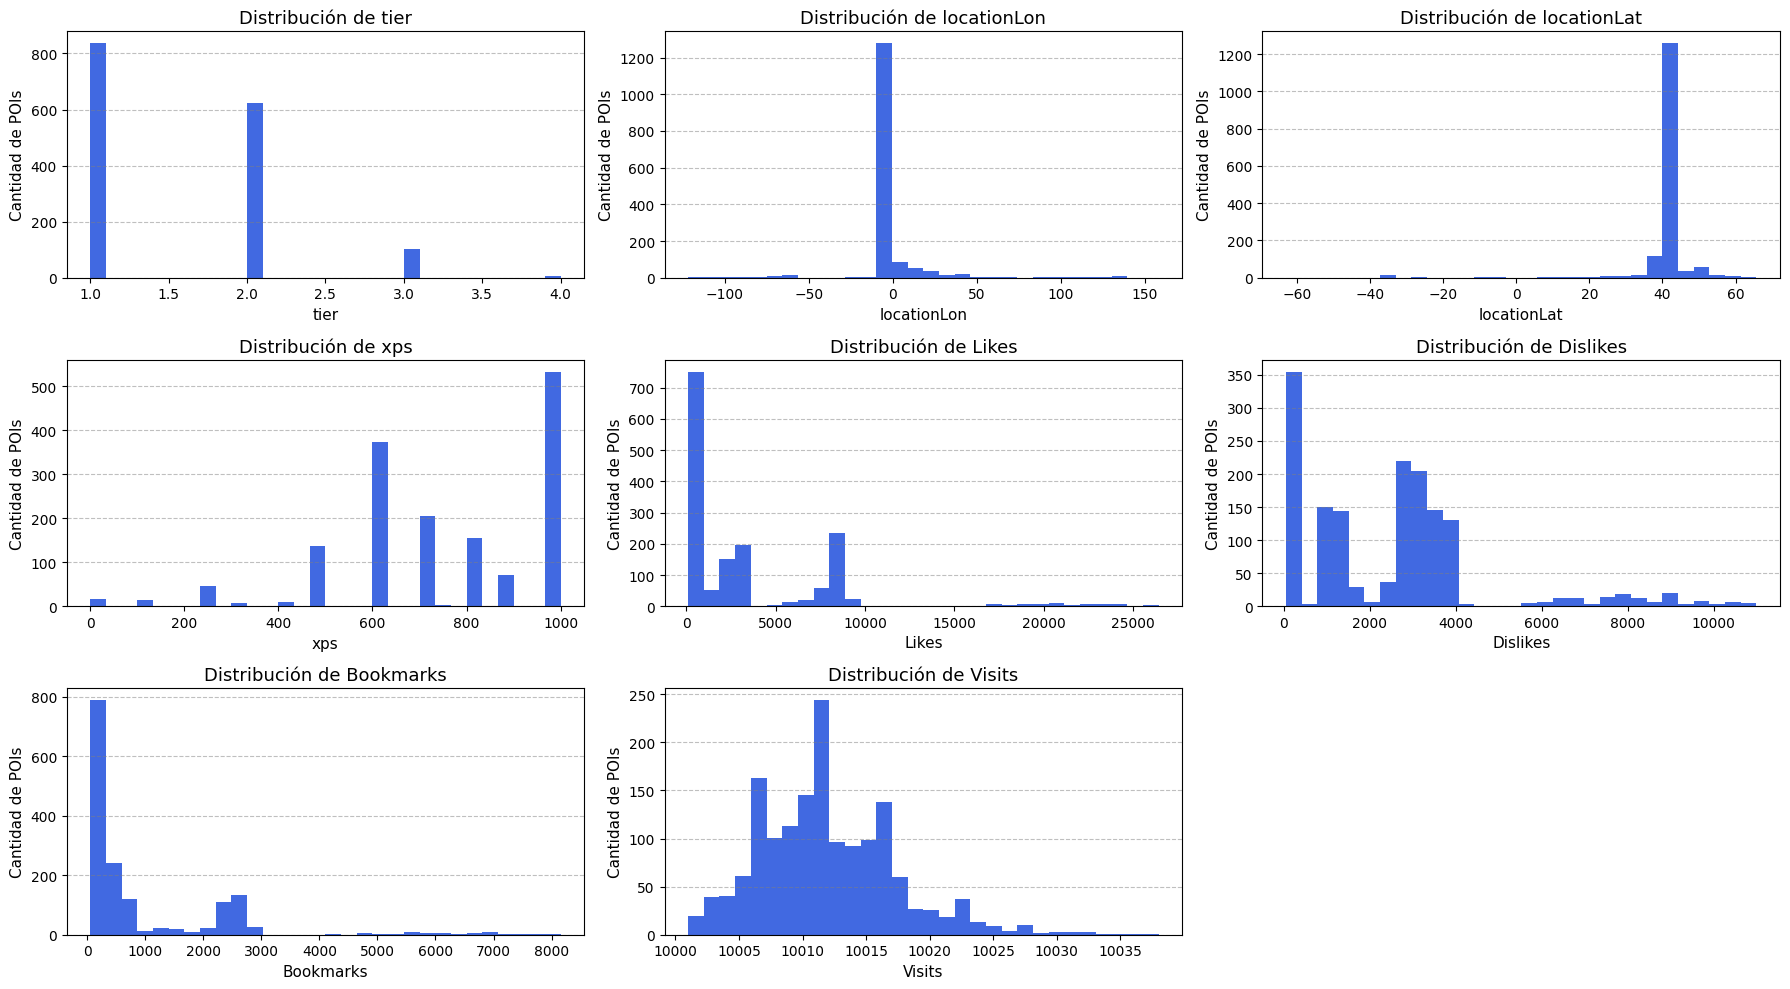

In [19]:
# Histograma de las variables numéricas
# Seleccionar columnas numéricas
numeric_cols = ['tier', 'locationLon', 'locationLat', 'xps', 'Likes', 'Dislikes', 'Bookmarks', 'Visits']

# Crear figura
plt.figure(figsize=(18, 10))

# Generar subplots de 3 columnas por fila
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    plt.hist(df[col].dropna(), bins=30, color='#4169E1')

    plt.xlabel(col, fontsize=11)
    plt.ylabel('Cantidad de POIs', fontsize=11)
    plt.title(f'Distribución de {col}', fontsize=13)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.5, linestyle='--', color='gray')

plt.tight_layout()
plt.show()

In [20]:
# Contar valores únicos que tiene la variable 'xps'
# Mostrar la distribución de frecuencias de cada valor de 'xps'
val_unicos_xps = df['xps'].nunique()
print(f"Número de valores únicos en xps: {val_unicos_xps}")
print(df['xps'].value_counts().sort_index())

Número de valores únicos en xps: 13
xps
0        16
100      13
150       1
250      46
300       7
400      10
500     137
600     372
700     206
750       2
800     155
900      71
1000    533
Name: count, dtype: int64


In [21]:
# Contar valores únicos que tiene la variable 'tier'
# Mostrar la distribución de frecuencias de cada valor de 'tier'
val_unicos_tier = df['tier'].nunique()
print(f"Número de valores únicos en tier: {val_unicos_tier}")
print(df['tier'].value_counts().sort_index())

Número de valores únicos en tier: 4
tier
1    837
2    622
3    103
4      7
Name: count, dtype: int64


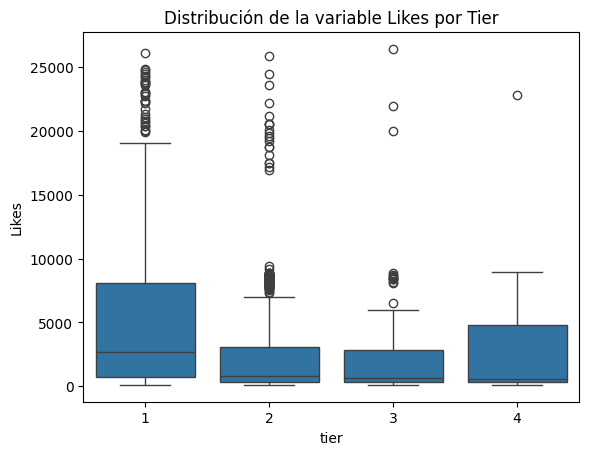

In [22]:
# Boxplot variables 'Likes' por 'tier
sns.boxplot(x=df['tier'], y=df['Likes'])
plt.title("Distribución de la variable Likes por Tier")
plt.show()

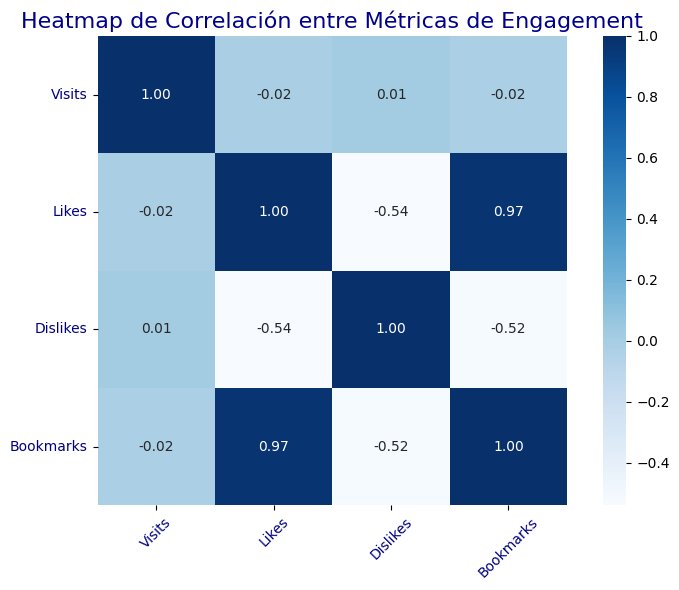

In [23]:
# Heatmap correlación de las métricas de engagement
engagement_cols = ['Visits', 'Likes', 'Dislikes', 'Bookmarks']

# Calcular la matriz de correlación
corr_matrix = df[engagement_cols].corr()

# Heatmap con degradado en tonos de azul
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', square=True)
plt.title('Heatmap de Correlación entre Métricas de Engagement', fontsize=16, color='darkblue')
plt.xticks(rotation=45, color='navy')
plt.yticks(rotation=0, color='navy')
plt.tight_layout()
plt.show()

### 1.3 Codificación variables categóricas

In [24]:
# Codificar la variable 'categories' con MultiLabelBinarizer
mlb = MultiLabelBinarizer()
df_mlb = pd.DataFrame(mlb.fit_transform(df["categories"]), columns=mlb.classes_)
df_mlb.head()

,Arquitectura,Ciencia,Cine,Cultura,Escultura,Gastronomía,Historia,Misterio,Naturaleza,Ocio,Patrimonio,Pintura
0,0,0,0,0,1,0,0,0,0,0,0,1
1,0,0,0,0,0,0,1,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,0,1,0
3,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,1,0


In [25]:
# Juntamos el one-hot con el dataframe original
df = pd.concat([df, df_mlb], axis=1)
df.head()


,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,...,Cine,Cultura,Escultura,Gastronomía,Historia,Misterio,Naturaleza,Ocio,Patrimonio,Pintura
0,"[Escultura, Pintura]",1,2.642262,39.572694,[],500,10009,422,3582,78,...,0,0,1,0,0,0,0,0,0,1
1,"[Patrimonio, Historia]",1,-3.704467,40.423037,[],500,10010,7743,96,2786,...,0,0,0,0,1,0,0,0,1,0
2,"[Ciencia, Patrimonio]",2,-3.699694,40.442045,[],250,10015,3154,874,595,...,0,0,0,0,0,0,0,0,1,0
3,[Cultura],1,-3.691228,40.427256,[],500,10011,8559,79,2358,...,0,1,0,0,0,0,0,0,0,0
4,"[Patrimonio, Cultura]",1,-3.727822,40.439665,[],500,10020,915,2896,143,...,0,1,0,0,0,0,0,0,1,0


In [26]:
# Eliminamos la columna 'categories' del dataset
df.drop(columns=['categories'], inplace=True)

In [27]:
# Crear columnas multi-hot para cada tag del Top10
for tag in top10_tags:
    df[f'tag_{tag}'] = df['tags'].apply(lambda lst: int(tag in lst))

# Añadimos columna 'tag_other' para cualquier tag que no se encunetre en el top 10
df['tag_other'] = df['tags'].apply(lambda lst: int(any(t not in top10_tags for t in lst)))

# Eliminamos la columna 'tags' del dataset
df.drop(columns=['tags'], inplace=True)

df.head()

,tier,locationLon,locationLat,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path,Arquitectura,...,tag_Madrid,tag_Cultura,tag_Arquitectura,tag_Patrimonio,tag_Arte,tag_Escultura,tag_Estatua,tag_Monumento,tag_Naturaleza,tag_other
0,1,2.642262,39.572694,500,10009,422,3582,78,data_main/4b36a3ed-3b28-4bc7-b975-1d48b586db03...,0,...,0,0,0,0,0,0,0,0,0,0
1,1,-3.704467,40.423037,500,10010,7743,96,2786,data_main/e32b3603-a94f-49df-8b31-92445a86377c...,0,...,0,0,0,0,0,0,0,0,0,0
2,2,-3.699694,40.442045,250,10015,3154,874,595,data_main/0123a69b-13ac-4b65-a5d5-71a95560cff5...,0,...,0,0,0,0,0,0,0,0,0,0
3,1,-3.691228,40.427256,500,10011,8559,79,2358,data_main/390d7d9e-e972-451c-b5e4-f494af15e788...,0,...,0,0,0,0,0,0,0,0,0,0
4,1,-3.727822,40.439665,500,10020,915,2896,143,data_main/023fc1bf-a1cd-4b9f-af78-48792ab1a294...,0,...,0,0,0,0,0,0,0,0,0,0


### 1.4 Creación de la variable target

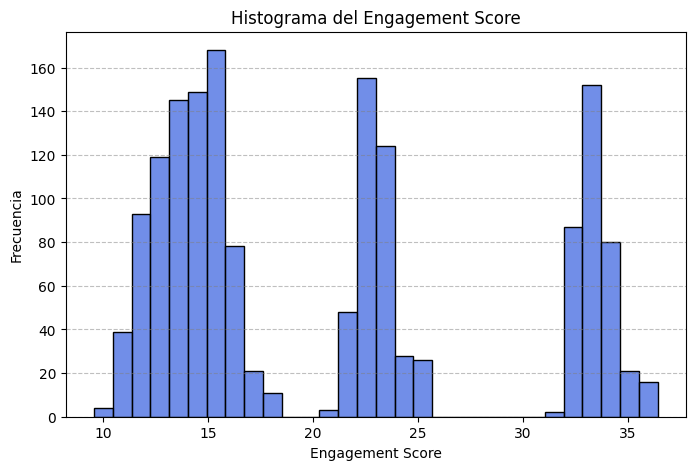

In [28]:
# Crear la variable engagement_score
# Pasamos a escala logarítmica las variables del engagement
df['log_visits']    = np.log1p(df['Visits'])
df['log_likes']     = np.log1p(df['Likes'])
df['log_dislikes']  = np.log1p(df['Dislikes'])
df['log_bookmarks'] = np.log1p(df['Bookmarks'])

# Calculamos el engagement_score como suma ponderada de cada variable
df['engagement_score'] = (1.0  * df['log_visits'] + 1.5 * df['log_likes'] + 2.5 * df['log_bookmarks'] - 2.0 * df['log_dislikes'])

# Histograma
plt.figure(figsize=(8, 5))
sns.histplot(df['engagement_score'], bins=30, color='#4169E1')
plt.title('Histograma del Engagement Score')
plt.xlabel('Engagement Score')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.5, linestyle='--', color='gray')
plt.show()

In [29]:
# Estadística de la variable 'engagement_score'
print(df["engagement_score"].describe())

count    1569.000000
mean       20.682256
std         7.999699
min         9.578371
25%        14.005216
50%        16.425519
75%        24.566047
max        36.419854
Name: engagement_score, dtype: float64


In [30]:
# Definir cut-points para engagement score:
bins = [-np.inf, 19, 30, np.inf]
labels = [0, 1, 2]  # 0 = bajo, 1 = medio, 2 = alto

# Crear la nueva columna 'engagement_score'
df['engagement_level'] = pd.cut(df['engagement_score'], bins=bins, labels=labels).astype(int)

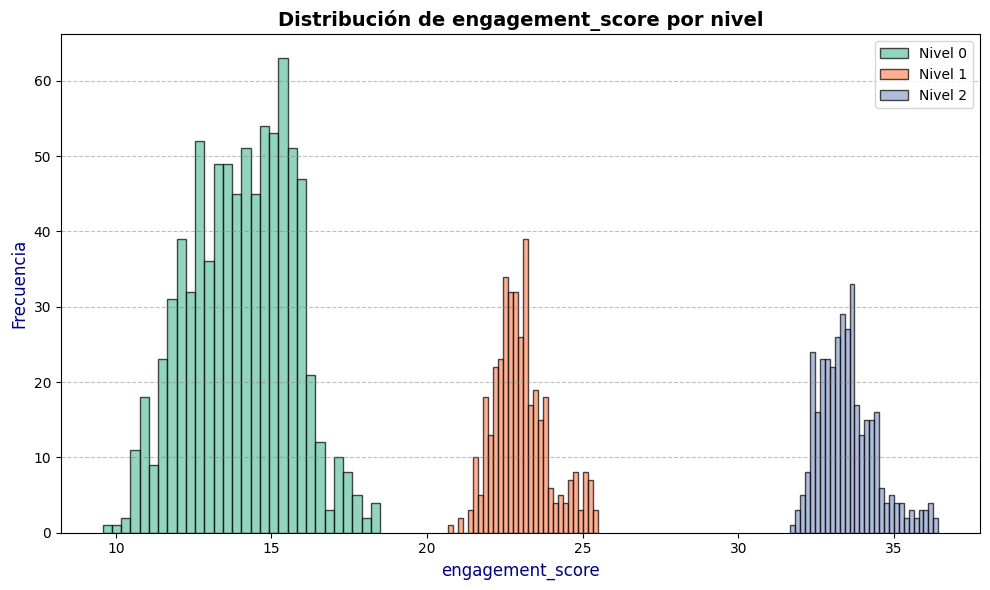

In [31]:
# Histograma niveles de engagement
plt.figure(figsize=(10, 6))
labels = [0, 1, 2]
colors = ['#66c2a5', '#fc8d62', '#8da0cb']

for i, label in enumerate(labels):
    subset = df[df["engagement_level"] == label]
    plt.hist(subset["engagement_score"], bins=30, alpha=0.7, color=colors[i], label=f'Nivel {label}', edgecolor='black')

plt.title("Distribución de engagement_score por nivel", fontsize=14, fontweight='bold', color='black')
plt.xlabel("engagement_score", fontsize=12, color='navy')
plt.ylabel("Frecuencia", fontsize=12, color='navy')
plt.legend()
plt.grid(axis='y', alpha=0.5, linestyle='--', color='gray')
plt.tight_layout()
plt.show()

In [32]:
# Eliminamos la columna 'engagement_score', "Visits", "Likes", "Dislikes" y "Bookmarks"
df.drop(columns=["engagement_score", "Visits", "Dislikes", "Likes", "Bookmarks"], inplace=True)

In [33]:
# Contar la frecuencia de cada nivel de engagement
print("Distribución de engagement_level:")
print(df['engagement_level'].value_counts())

Distribución de engagement_level:
engagement_level
0    827
1    384
2    358
Name: count, dtype: int64


In [34]:
# Estructura final del Dataframe
print(df.dtypes)
print(df.shape)
df.head()

tier                  int64
locationLon         float64
locationLat         float64
xps                   int64
main_image_path      object
Arquitectura          int64
Ciencia               int64
Cine                  int64
Cultura               int64
Escultura             int64
Gastronomía           int64
Historia              int64
Misterio              int64
Naturaleza            int64
Ocio                  int64
Patrimonio            int64
Pintura               int64
tag_Historia          int64
tag_Madrid            int64
tag_Cultura           int64
tag_Arquitectura      int64
tag_Patrimonio        int64
tag_Arte              int64
tag_Escultura         int64
tag_Estatua           int64
tag_Monumento         int64
tag_Naturaleza        int64
tag_other             int64
log_visits          float64
log_likes           float64
log_dislikes        float64
log_bookmarks       float64
engagement_level      int64
dtype: object
(1569, 33)


,tier,locationLon,locationLat,xps,main_image_path,Arquitectura,Ciencia,Cine,Cultura,Escultura,...,tag_Escultura,tag_Estatua,tag_Monumento,tag_Naturaleza,tag_other,log_visits,log_likes,log_dislikes,log_bookmarks,engagement_level
0,1,2.642262,39.572694,500,data_main/4b36a3ed-3b28-4bc7-b975-1d48b586db03...,0,0,0,0,1,...,0,0,0,0,0,9.211340,6.047372,8.183956,4.369448,0
1,1,-3.704467,40.423037,500,data_main/e32b3603-a94f-49df-8b31-92445a86377c...,0,0,0,0,0,...,0,0,0,0,0,9.211440,8.954674,4.574711,7.932721,2
2,2,-3.699694,40.442045,250,data_main/0123a69b-13ac-4b65-a5d5-71a95560cff5...,0,1,0,0,0,...,0,0,0,0,0,9.211939,8.056744,6.774224,6.390241,1
3,1,-3.691228,40.427256,500,data_main/390d7d9e-e972-451c-b5e4-f494af15e788...,0,0,0,1,0,...,0,0,0,0,0,9.211540,9.054855,4.382027,7.765993,2
4,1,-3.727822,40.439665,500,data_main/023fc1bf-a1cd-4b9f-af78-48792ab1a294...,0,0,0,1,0,...,0,0,0,0,0,9.212438,6.820016,7.971431,4.969813,0


### 1.5 Exploración de las imágenes

In [35]:
# Mostrar las primeras rutas de las imágenes
print(df['main_image_path'].head())

0    data_main/4b36a3ed-3b28-4bc7-b975-1d48b586db03...
1    data_main/e32b3603-a94f-49df-8b31-92445a86377c...
2    data_main/0123a69b-13ac-4b65-a5d5-71a95560cff5...
3    data_main/390d7d9e-e972-451c-b5e4-f494af15e788...
4    data_main/023fc1bf-a1cd-4b9f-af78-48792ab1a294...
Name: main_image_path, dtype: object


In [36]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

BASE = Path("Data")
IMG_EXTS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

def resolve_image(rel_path: str) -> Path | None:
    """Devuelve una ruta existente para la imagen o None si no se encuentra."""
    rel = Path(rel_path.strip().lstrip("/"))
    p = BASE / rel
    if p.exists():
        return p

    parent = p.parent
    if not parent.exists():
        return None

    # 1) probar main.* en ese directorio
    for ext in IMG_EXTS:
        q = parent / f"main{ext}"
        if q.exists():
            return q

    # 2) si no hay main.*, tomar la primera imagen disponible
    for q in parent.iterdir():
        if q.is_file() and q.suffix in IMG_EXTS:
            return q

    return None

# ---- Resolver rutas del DF ----
rel_series = df["main_image_path"].dropna().astype(str).tolist()
resolved_paths = []
missing_files = 0
missing_dirs = 0

for rel in tqdm(rel_series, desc="Resolviendo rutas"):
    rel_clean = rel.strip().lstrip("/")
    p = BASE / rel_clean
    parent = p.parent
    if not parent.exists():
        missing_dirs += 1
        continue
    rp = resolve_image(rel)
    if rp is None:
        missing_files += 1
    else:
        resolved_paths.append(rp)

total = len(rel_series)
print(
    f"Total filas DF: {total} | Resueltas: {len(resolved_paths)} | "
    f"Dirs inexistentes: {missing_dirs} | Sin imagen en dir: {missing_files}"
)

# ---- Contar tamaños sólo en imágenes válidas ----
size_counter = Counter()
errores_lectura = 0

for img_path in tqdm(resolved_paths, desc="Contando tamaños de imagen"):
    try:
        with Image.open(img_path) as img:
            size_counter[img.size] += 1
    except (UnidentifiedImageError, OSError):
        errores_lectura += 1

print(f"\nImágenes válidas procesadas: {sum(size_counter.values())}")
print(f"Errores de lectura: {errores_lectura}")

print("\nTamaños de imagen más frecuentes:")
for (w, h), count in size_counter.most_common(10):
    print(f"{w}x{h}: {count}")



Resolviendo rutas: 100%|██████████| 1569/1569 [02:05<00:00, 12.49it/s] 


Total filas DF: 1569 | Resueltas: 1536 | Dirs inexistentes: 33 | Sin imagen en dir: 0


Contando tamaños de imagen: 100%|██████████| 1536/1536 [19:39<00:00,  1.30it/s]


Imágenes válidas procesadas: 1536
Errores de lectura: 0

Tamaños de imagen más frecuentes:
128x128: 1536


In [37]:
# Seleccionamos 25 imágenes aleatorias del
base_path = Path("Data")
sample_images = df.sample(n=25, random_state=42)

plt.figure(figsize=(20, 20))

for idx, (_, row) in enumerate(sample_images.iterrows()):
    # Construir la ruta completa a la imagen
    image_path = base_path / row['main_image_path'].strip().lstrip("/")

    if not image_path.exists():
        print(f"No se encontró la imagen: {image_path}")
        continue

    img = cv2.imread(str(image_path))  # OpenCV necesita str

    if img is None:
        print(f"No se pudo cargar la imagen: {image_path}")
        continue

    # Convertir de BGR a RGB para Matplotlib
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(5, 5, idx + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Tier {row['tier']}", fontsize=10)

plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

### 1.7 Creación Dataset personalizado y división de los datos





In [38]:
# Dataset para POIs
class POIDataset(Dataset):
    """
    Conjunto de datos para POIs compatible con PyTorch DataLoader.

    Args:
       target (array-like): etiquetas de clase (0, 1, 2).
       image_paths (array-like[str|Path]): rutas de imágenes.
       features (array-like): datos tabulares alineados con las etiquetas.
       transform: transformaciones de imagen.
      root_dir (str|Path, opcional): carpeta base para completar rutas relativas.
    """
    def __init__(self, target, image_paths, features, transform=None, root_dir=None):
        assert len(target) == len(features) == len(image_paths)

        self.target = torch.tensor(target, dtype=torch.long)
        self.features = torch.tensor(features, dtype=torch.float)
        self.transform = transform

        self.root_dir = Path(root_dir) if root_dir is not None else None

        self.image_paths = []
        for p in image_paths:
            p = Path(str(p).strip())
            if self.root_dir is not None and not p.is_absolute():
                p = self.root_dir / p
            self.image_paths.append(p)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        with Image.open(img_path).convert("RGB") as img:
            image = self.transform(img) if self.transform is not None else img

        y = self.target[idx]
        x = self.features[idx]
        return image, y, x


In [39]:
# Dividimos el dataframe en train/val/test estratificados
train_val_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df['engagement_level'], random_state=SEED
)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.15, stratify=train_val_df['engagement_level'], random_state=SEED
)

# Copias para evitar SettingWithCopy
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

# Normalizamos columnas numéricas
cols_to_scale = ['xps', 'locationLat', 'locationLon']
scaler = StandardScaler()
train_df[cols_to_scale] = scaler.fit_transform(train_df[cols_to_scale])
val_df[cols_to_scale]   = scaler.transform(val_df[cols_to_scale])
test_df[cols_to_scale]  = scaler.transform(test_df[cols_to_scale])

# Seleccionamos columnas de features (excluyendo columnas no usadas)
excluded_cols = ['engagement_level', 'main_image_path',
                 'log_visits', 'log_likes', 'log_dislikes', 'log_bookmarks']
feature_cols = [c for c in train_df.columns if c not in excluded_cols]

# Construir rutas absolutas y filtrar las que no existen
BASE = Path("Data")

def to_abs(p):
    """Prepara ruta absoluta partiendo de la columna main_image_path"""
    return (BASE / str(p).strip().lstrip("/"))

def resolve_and_filter(df_split: pd.DataFrame) -> pd.DataFrame:
    """Añade columna con ruta absoluta y elimina filas sin fichero"""
    out = df_split.copy()
    out["img_path_abs"] = out["main_image_path"].apply(to_abs)
    out = out[out["img_path_abs"].apply(lambda p: Path(p).exists())]
    return out

train_df = resolve_and_filter(train_df)
val_df   = resolve_and_filter(val_df)
test_df  = resolve_and_filter(test_df)

# Preparar arrays para Dataset
X_train = train_df[feature_cols].to_numpy()
y_train = train_df['engagement_level'].to_numpy()
img_paths_train = train_df['img_path_abs'].to_numpy()

X_val = val_df[feature_cols].to_numpy()
y_val = val_df['engagement_level'].to_numpy()
img_paths_val = val_df['img_path_abs'].to_numpy()

X_test = test_df[feature_cols].to_numpy()
y_test = test_df['engagement_level'].to_numpy()
img_paths_test = test_df['img_path_abs'].to_numpy()

print("Tamaño Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Tamaño Train: (1105, 27) | Val: (198, 27) | Test: (233, 27)


In [40]:
# Transforms con data augmentation (para train)
weights = models.ResNet18_Weights.IMAGENET1K_V1
base_tfms = weights.transforms()  #  Resize(232) + CenterCrop(224) + ToTensor + Normalize

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    base_tfms,  # normalización ImageNet
])

val_test_transform = base_tfms  # validación/test sin augmentación extra

In [41]:
# Crear Datasets y Dataloaders
train_dataset = POIDataset(y_train, img_paths_train, X_train, transform=train_transform)
val_dataset   = POIDataset(y_val,   img_paths_val,   X_val,   transform=val_test_transform)
test_dataset  = POIDataset(y_test,  img_paths_test,  X_test,  transform=val_test_transform)

BATCH_SIZE = 256
pin = torch.cuda.is_available()

# Generador determinista para shuffle de train
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, generator=g,
    num_workers=0, pin_memory=pin
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0, pin_memory=pin
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0, pin_memory=pin
)

print(f"Batches por epoch (train): {len(train_loader)}")

Batches por epoch (train): 5


## **2. Arquitectura del Modelo**

In [42]:
# Modelo Multimodal (imágenes + metadatos)
class POIMultimodalModel(nn.Module):
    def __init__(self, metadata_dim, hidden_dim=128, dropout_rate=0.4,
                 activation_fn=nn.ELU, freeze_backbone=False):
        super().__init__()

        # 1) ResNet18 con API moderna
        weights = models.ResNet18_Weights.IMAGENET1K_V1
        self.resnet = models.resnet18(weights=weights)
        self.resnet_output_dim = self.resnet.fc.in_features  # 512 for resnet18
        self.resnet.fc = nn.Identity()

        if freeze_backbone:
            for p in self.resnet.parameters():
                p.requires_grad = False

        # Rama metadatos
        self.meta_branch = nn.Sequential(
            nn.Linear(metadata_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            activation_fn(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            activation_fn()
        )

        # Fusión y Clasificación
        fusion_in = self.resnet_output_dim + hidden_dim
        self.fusion_branch = nn.Sequential(
            nn.Linear(fusion_in, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            activation_fn(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 3)  # 3 classes
        )

    def forward(self, image, metadata):
        img_feat = self.resnet(image)
        meta_feat = self.meta_branch(metadata)
        fused = torch.cat([img_feat, meta_feat], dim=1)
        logits = self.fusion_branch(fused)
        return logits

In [43]:
# Instanciar el modelo
model = POIMultimodalModel(
    metadata_dim=X_train.shape[1],
    hidden_dim=128,
    dropout_rate=0.4,
    activation_fn=nn.ELU,
    freeze_backbone=False
).to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 213MB/s]


In [44]:
# Comprobación rápida: forward de un batch
images, labels, metadata = next(iter(train_loader))
images = images.to(device)
metadata = metadata.to(device)
labels = labels.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images, metadata)

print("Shape de salida:", outputs.shape)

Shape de salida: torch.Size([256, 3])


## **3. Entrenamiento y Optimización**

### 3.1 Baseline del modelo (backbone congelado)

In [45]:
# Función para entrenamiento y validación del modelo
def POI_train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    weight_decay=3e-5,
    learning_rate=1e-3,
    num_epochs=30,
    early_stopping=5,
    scheduler=None,
    use_adamw=True,
    lr_backbone=None,
    restore_best=True,
    verbose=True,
):
    """
    Entrena tu modelo usando tus funciones train_epoch y eval_epoch.

    - Usa AdamW por defecto.
    - ReduceLROnPlateau como scheduler por defecto.
    - Early stopping sobre val_acc.
    - LR discriminativo (backbone vs cabeza) si se pasa lr_backbone.
    """

    device = next(model.parameters()).device
    if verbose:
        print(f"[INFO] Device: {device} | LR head: {learning_rate} | "
              f"LR backbone: {lr_backbone if lr_backbone is not None else '-'} | "
              f"Epochs: {num_epochs}")

    # ─── OPTIMIZADOR ───
    Optim = AdamW if use_adamw else optim.Adam

    if (lr_backbone is not None) and hasattr(model, "resnet"):
        head_params, bb_params = [], []
        for n, p in model.named_parameters():
            if not p.requires_grad:
                continue
            (bb_params if n.startswith("resnet.") else head_params).append(p)
        optimizer = Optim(
            [
                {"params": bb_params,  "lr": lr_backbone},
                {"params": head_params, "lr": learning_rate},
            ],
            weight_decay=weight_decay,
        )
        get_lr = lambda: (optimizer.param_groups[0]["lr"], optimizer.param_groups[1]["lr"])
    else:
        optimizer = Optim(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        get_lr = lambda: (optimizer.param_groups[0]["lr"],)

    # ─── SCHEDULER ───
    if scheduler is None:
        scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    # ─── TRACKING ───
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    lrs_log = []

    best_val_acc = -float("inf")
    best_model_state = None
    patience_counter = 0

    # ─── LOOP ───
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc, _ = train_epoch(
            model=model,
            device=device,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer
        )

        val_loss, val_acc = eval_epoch(
            model=model,
            device=device,
            val_loader=val_loader,
            criterion=criterion
        )

        # ReduceLROnPlateau necesita la métrica monitorizada
        old_lrs = tuple(pg['lr'] for pg in optimizer.param_groups)
        if isinstance(scheduler, ReduceLROnPlateau):
            scheduler.step(val_acc)
        else:
            scheduler.step()
        new_lrs = tuple(pg['lr'] for pg in optimizer.param_groups)

        train_losses.append(train_loss); val_losses.append(val_loss)
        train_accs.append(train_acc);   val_accs.append(val_acc)
        lrs_log.append(new_lrs)

        # Imprimir progreso
        if verbose:
            if lr_backbone is not None and hasattr(model, "resnet"):
                lr_bb, lr_hd = new_lrs if len(new_lrs) == 2 else (new_lrs[0], new_lrs[0])
                print(f"[Epoch {epoch:02d}] tr_loss={train_loss:.4f} acc={train_acc:.2f}% | "
                      f"val_loss={val_loss:.4f} acc={val_acc:.2f}% | "
                      f"LR(bb)={lr_bb:.2e} LR(head)={lr_hd:.2e}")
            else:
                (lr0,) = new_lrs
                print(f"[Epoch {epoch:02d}] tr_loss={train_loss:.4f} acc={train_acc:.2f}% | "
                      f"val_loss={val_loss:.4f} acc={val_acc:.2f}% | LR={lr0:.2e}")

        # Early stopping
        if val_acc > best_val_acc + 1e-6:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stopping:
                if verbose:
                    print(f"[INFO] Early stopping en epoch {epoch}.")
                break

    best_epoch = int(np.argmax(val_accs)) + 1
    if verbose:
        print(f"[INFO] Mejor epoch: {best_epoch} | Best Val Acc: {val_accs[best_epoch - 1]:.2f}%")

    # Curvas (si tus funciones existen)
    try:
        plot_training_curves(train_losses, val_losses, train_accs, val_accs)
        plot_learning_rate(lrs_log)
    except Exception:
        pass

    if restore_best and best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, (train_losses, val_losses, train_accs, val_accs), best_model_state, best_val_acc


In [46]:
# Calcular pesos de clase para equilibrar la pérdida
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

# Definir la función de pérdida ponderada
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

[INFO] Device: cuda:0 | LR head: 0.001 | LR backbone: - | Epochs: 25
[Epoch 01] tr_loss=0.9024 acc=55.93% | val_loss=0.8354 acc=64.65% | LR=1.00e-03
[Epoch 02] tr_loss=0.6281 acc=77.38% | val_loss=0.6784 acc=77.78% | LR=1.00e-03
[Epoch 03] tr_loss=0.5421 acc=79.10% | val_loss=0.5959 acc=79.29% | LR=1.00e-03
[Epoch 04] tr_loss=0.5045 acc=85.16% | val_loss=0.5680 acc=80.30% | LR=1.00e-03
[Epoch 05] tr_loss=0.4765 acc=87.33% | val_loss=0.5258 acc=84.34% | LR=1.00e-03
[Epoch 06] tr_loss=0.4550 acc=88.05% | val_loss=0.4875 acc=86.36% | LR=1.00e-03
[Epoch 07] tr_loss=0.4124 acc=89.50% | val_loss=0.4811 acc=85.86% | LR=1.00e-03
[Epoch 08] tr_loss=0.4223 acc=89.50% | val_loss=0.4803 acc=85.86% | LR=1.00e-03
[Epoch 09] tr_loss=0.4025 acc=90.32% | val_loss=0.4839 acc=86.36% | LR=5.00e-04
[Epoch 10] tr_loss=0.4027 acc=90.41% | val_loss=0.4798 acc=86.36% | LR=5.00e-04
[Epoch 11] tr_loss=0.3900 acc=91.76% | val_loss=0.4742 acc=85.35% | LR=5.00e-04
[INFO] Early stopping en epoch 11.
[INFO] Mejor epo

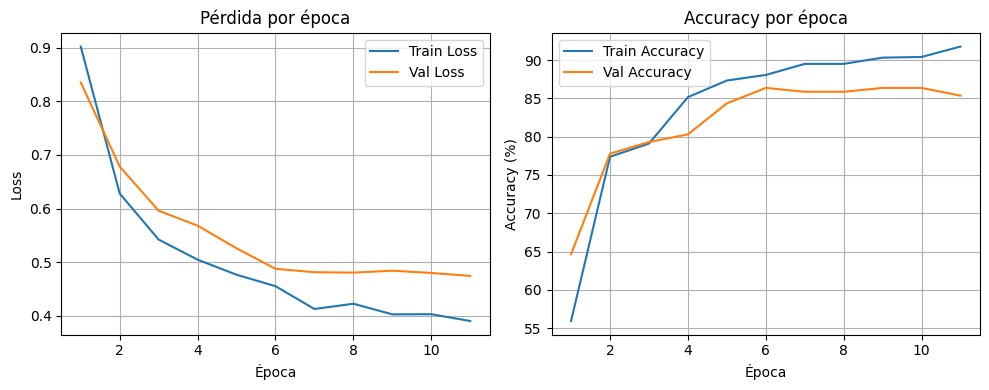

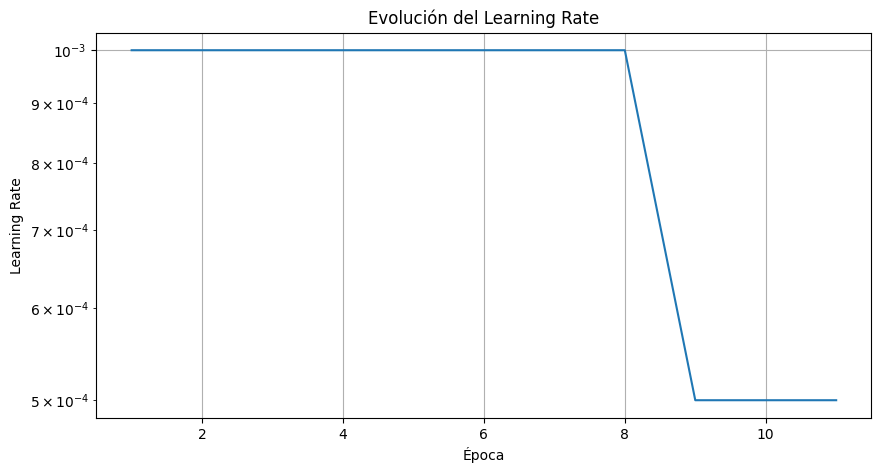

In [47]:
# Congelar backbone (baseline estable)
for p in model.resnet.parameters():
    p.requires_grad = False

model, hist, best_state, best_val = POI_train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    weight_decay=3e-5,
    learning_rate=1e-3,
    num_epochs=25,
    early_stopping=5,
    scheduler=None,
    use_adamw=True,
    lr_backbone=None,
    restore_best=True,
)

### 3.2 *Fine-tuning* parcial del backbone

Descongelamos la ResNet, usamos LRs discriminativos (cabeza > backbone) y aumentamos label smoothing a 0.08.**texto en negrita**

[INFO] Device: cuda:0 | LR head: 0.0005 | LR backbone: 5e-05 | Epochs: 25
[Epoch 01] tr_loss=0.5177 acc=87.69% | val_loss=0.5347 acc=85.86% | LR(bb)=5.00e-05 LR(head)=5.00e-04
[Epoch 02] tr_loss=0.4373 acc=93.48% | val_loss=0.5433 acc=87.88% | LR(bb)=5.00e-05 LR(head)=5.00e-04
[Epoch 03] tr_loss=0.4086 acc=94.39% | val_loss=0.5343 acc=88.89% | LR(bb)=5.00e-05 LR(head)=5.00e-04
[Epoch 04] tr_loss=0.4022 acc=95.02% | val_loss=0.5068 acc=89.90% | LR(bb)=5.00e-05 LR(head)=5.00e-04
[Epoch 05] tr_loss=0.3819 acc=96.29% | val_loss=0.5061 acc=87.88% | LR(bb)=5.00e-05 LR(head)=5.00e-04
[Epoch 06] tr_loss=0.3782 acc=96.38% | val_loss=0.4877 acc=90.91% | LR(bb)=5.00e-05 LR(head)=5.00e-04
[Epoch 07] tr_loss=0.3683 acc=96.47% | val_loss=0.4967 acc=89.90% | LR(bb)=5.00e-05 LR(head)=5.00e-04
[Epoch 08] tr_loss=0.3623 acc=96.38% | val_loss=0.5035 acc=90.40% | LR(bb)=5.00e-05 LR(head)=5.00e-04
[Epoch 09] tr_loss=0.3787 acc=96.83% | val_loss=0.5005 acc=88.89% | LR(bb)=2.50e-05 LR(head)=2.50e-04
[Epoch 1

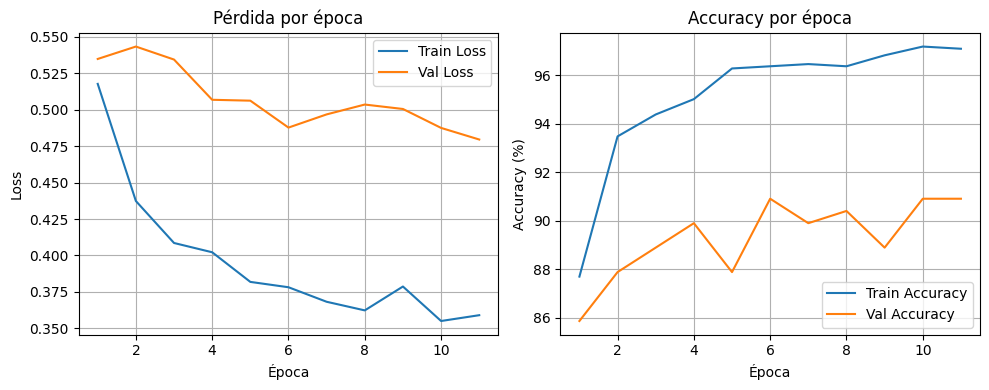

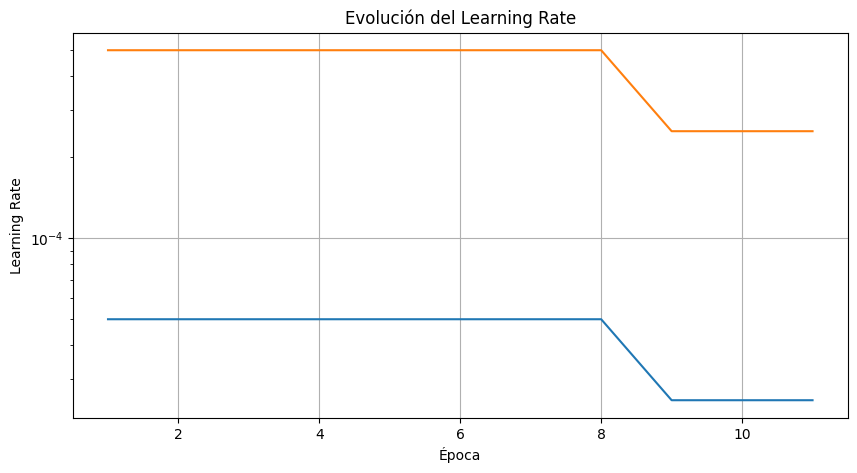

Val acc (FT parcial): 90.91%


In [48]:
# Descongelar el backbone
for p in model.resnet.parameters():
    p.requires_grad = True

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.08)

model, hist2, best_state2, best_val2 = POI_train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    weight_decay=3e-5,
    learning_rate=5e-4,
    num_epochs=25,
    early_stopping=5,
    scheduler=None,
    use_adamw=True,
    lr_backbone=5e-5,
    restore_best=True,
    verbose=True
)

print(f"Val acc (FT parcial): {best_val2:.2f}%")


### 3.3 Optimización de hiperparámetros con Optuna

In [49]:

def objective(trial):
    # ── Hiperparámetros
    lr_head      = trial.suggest_float("lr_head", 2e-4, 1e-3, log=True)
    lr_backbone  = trial.suggest_float("lr_backbone", 1e-5, 2e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 3e-4, log=True)
    dropout      = trial.suggest_float("dropout", 0.30, 0.60)
    smoothing    = trial.suggest_float("label_smoothing", 0.03, 0.12)

    # ── Modelo por trial (backbone NO congelado)
    m = POIMultimodalModel(
        metadata_dim=X_train.shape[1],
        hidden_dim=128,
        dropout_rate=dropout,
        activation_fn=nn.ELU,
        freeze_backbone=False
    ).to(device)

    # ── Criterion con class_weights + smoothing
    crit = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=smoothing)

    # ── Entrenamiento
    _, _, _, best_val = POI_train_model(
        model=m,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=crit,
        weight_decay=weight_decay,
        learning_rate=lr_head,
        num_epochs=25,
        early_stopping=5,
        scheduler=None,
        use_adamw=True,
        lr_backbone=lr_backbone,
        restore_best=True,
        verbose=False
    )

    # Report a Optuna
    trial.report(best_val, step=0)
    return best_val


In [50]:
pruner = optuna.pruners.MedianPruner(n_startup_trials=6)
study = optuna.create_study(direction="maximize", pruner=pruner, study_name="poi_final_tuning")
study.optimize(objective, n_trials=40, gc_after_trial=True)

print("Mejores params:", study.best_params)
print("Mejor val_acc:", study.best_value)

Output hidden; open in https://colab.research.google.com to view.

[INFO] Device: cuda:0 | LR head: 0.0006833972368614762 | LR backbone: 2.3878316009804042e-05 | Epochs: 30
[Epoch 01] tr_loss=0.9908 acc=56.92% | val_loss=0.8920 acc=57.58% | LR(bb)=2.39e-05 LR(head)=6.83e-04
[Epoch 02] tr_loss=0.6629 acc=79.19% | val_loss=0.7187 acc=81.82% | LR(bb)=2.39e-05 LR(head)=6.83e-04
[Epoch 03] tr_loss=0.5716 acc=84.62% | val_loss=0.6363 acc=83.33% | LR(bb)=2.39e-05 LR(head)=6.83e-04
[Epoch 04] tr_loss=0.5401 acc=88.33% | val_loss=0.6001 acc=85.35% | LR(bb)=2.39e-05 LR(head)=6.83e-04
[Epoch 05] tr_loss=0.5236 acc=90.32% | val_loss=0.5857 acc=86.87% | LR(bb)=2.39e-05 LR(head)=6.83e-04
[Epoch 06] tr_loss=0.5014 acc=92.22% | val_loss=0.5765 acc=87.37% | LR(bb)=2.39e-05 LR(head)=6.83e-04
[Epoch 07] tr_loss=0.4767 acc=93.57% | val_loss=0.5739 acc=87.88% | LR(bb)=2.39e-05 LR(head)=6.83e-04
[Epoch 08] tr_loss=0.4686 acc=94.93% | val_loss=0.5639 acc=88.38% | LR(bb)=2.39e-05 LR(head)=6.83e-04
[Epoch 09] tr_loss=0.4715 acc=94.66% | val_loss=0.5548 acc=87.88% | LR(bb)=2.3

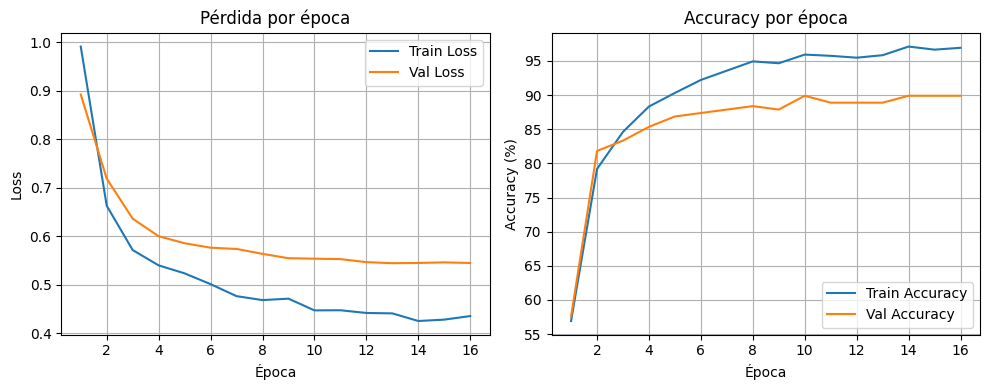

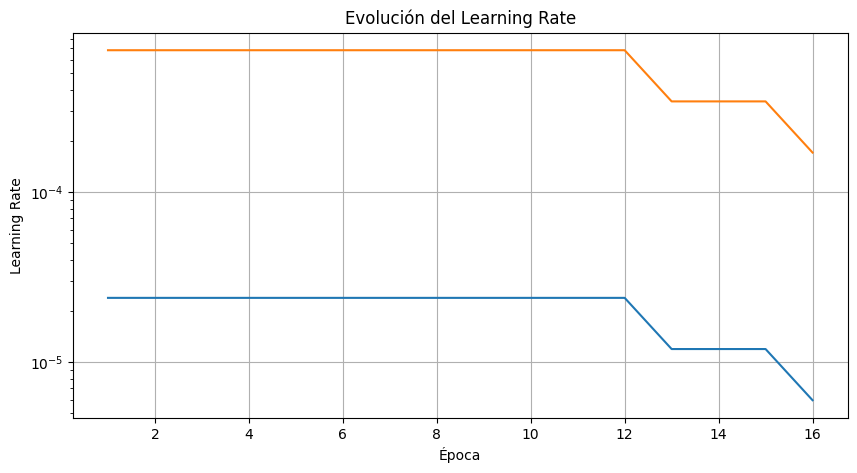

Modelo final guardado en: Models/best_model_final.pth


In [51]:
bp = study.best_params

# Reinstanciar modelo “final”
model_final = POIMultimodalModel(
    metadata_dim=X_train.shape[1],
    hidden_dim=128,
    dropout_rate=bp["dropout"],
    activation_fn=nn.ELU,
    freeze_backbone=False
).to(device)

criterion_final = nn.CrossEntropyLoss(
    weight=class_weights, label_smoothing=bp["label_smoothing"]
)

model_final, hist_final, best_state_final, best_val_final = POI_train_model(
    model=model_final,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_final,
    weight_decay=bp["weight_decay"],
    learning_rate=bp["lr_head"],
    num_epochs=30,
    early_stopping=6,
    scheduler=None,
    use_adamw=True,
    lr_backbone=bp["lr_backbone"],
    restore_best=True,
    verbose=True
)

# Guardar el mejor estado del modelo final en la carpeta Models
model_path = MODELS_DIR / "best_model_final.pth"
torch.save(best_state_final, model_path)
print(f"Modelo final guardado en: {model_path}")

In [63]:

resumen = pd.DataFrame([
    {"Experimento":"Baseline (backbone freeze)",
     "Val Acc (%)":89.39,
     "Notas":"AdamW, ls=0.05"},
    {"Experimento":"Fine-tuning parcial",
     "Val Acc (%)":90.91,
     "Notas":"lr_head=5e-4, lr_bb=5e-5"},
    {"Experimento":"Optuna (mejor)",
     "Val Acc (%)":89.90,
     "Notas":"Hparams Optuna (93.4 % en búsqueda) lr_head=6.8e-4, lr_bb=2.4e-5, wd≈3.0e-6, drop≈0.35, ls≈0.11"},
], columns=["Experimento","Val Acc (%)","Notas"])
display(resumen.style.format({"Val Acc (%)":"{:.2f}"}))


,Experimento,Val Acc (%),Notas
0,Baseline (backbone freeze),89.39,"AdamW, ls=0.05"
1,Fine-tuning parcial,90.91,"lr_head=5e-4, lr_bb=5e-5"
2,Optuna (mejor),89.90,"Hparams Optuna (93.4 % en búsqueda) lr_head=6.8e-4, lr_bb=2.4e-5, wd≈3.0e-6, drop≈0.35, ls≈0.11"


## **4. Evaluación y Análisis del Modelo**

In [54]:
# Cargar mejor modelo entrenado con Optuna
if best_state_final is not None:
    model_final.load_state_dict(best_state_final)
model_final.eval()

# Evaluación en test
acc_test, y_true, y_pred = evaluate_model(model_final, test_loader, device)

print(classification_report(y_true, y_pred, digits=4))
print(confusion_matrix(y_true, y_pred))

print(f"Test accuracy: {acc_test:.2f}%")

              precision    recall  f1-score   support

           0     0.9907    0.8770    0.9304       122
           1     0.8065    0.8621    0.8333        58
           2     0.7937    0.9434    0.8621        53

    accuracy                         0.8884       233
   macro avg     0.8636    0.8942    0.8753       233
weighted avg     0.9000    0.8884    0.8907       233

[[107   9   6]
 [  1  50   7]
 [  0   3  50]]
Test accuracy: 88.84%


### 4.1 Interpretabillidad y análisis de errores

### 4.1.1 Grad-CAM

In [55]:
# Separar aciertos y errores en dos grids (comparativo)

class ImageOnlyWrapper(nn.Module):
    def __init__(self, base_model, fixed_meta):
        super().__init__()
        self.base = base_model
        self.fixed_meta = fixed_meta
    def forward(self, x):
        m = self.fixed_meta
        if m.shape[0] != x.shape[0]:
            if m.shape[0] > x.shape[0]:
                m = m[:x.shape[0]]
            else:
                m = torch.cat([m, m[-1:].repeat(x.shape[0]-m.shape[0], 1)], dim=0)
        return self.base(x, m)

def denorm_01(x):
    x = x.detach().cpu().permute(1,2,0).numpy()
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)
    return x

def collect_gradcams(model, loader, device, max_ok=8, max_err=8, use_pred_targets=True):
    ok_imgs, ok_lbls, ok_preds, ok_cams = [], [], [], []
    er_imgs, er_lbls, er_preds, er_cams = [], [], [], []

    model.eval()

    for images, labels, meta in loader:
        images = images.to(device)
        meta   = meta.to(device)

        # Predicciones para decidir targets
        with torch.no_grad():
            logits = model(images, meta)
            preds  = logits.argmax(1)

        # Grad-CAM: activar gradientes y preparar entrada
        images.requires_grad_(True)

        wrapped = ImageOnlyWrapper(model, meta)
        target_layers = [wrapped.base.resnet.layer4[-1]]
        cam = GradCAM(model=wrapped, target_layers=target_layers)

        chosen  = preds if use_pred_targets else labels
        targets = [ClassifierOutputTarget(int(c.item())) for c in chosen]

        # Llamar a CAM con gradientes activados
        with torch.enable_grad():
            grayscale_cams = cam(input_tensor=images, targets=targets)

        # Recoger aciertos/errores
        for i in range(images.size(0)):
            img = denorm_01(images[i])
            lbl = int(labels[i].item())
            prd = int(preds[i].item())
            cam_i = grayscale_cams[i]

            if prd == lbl and len(ok_imgs) < max_ok:
                ok_imgs.append(img); ok_lbls.append(lbl); ok_preds.append(prd); ok_cams.append(cam_i)
            elif prd != lbl and len(er_imgs) < max_err:
                er_imgs.append(img); er_lbls.append(lbl); er_preds.append(prd); er_cams.append(cam_i)

        try:
            cam.activations_and_grads.release()
        except AttributeError:
            cam.clear_hooks()

        if len(ok_imgs) >= max_ok and len(er_imgs) >= max_err:
            break

    return (ok_imgs, ok_lbls, ok_preds, ok_cams), (er_imgs, er_lbls, er_preds, er_cams)

def show_grid(images, labels, preds, cams, title, cols=4):
    rows = ceil(len(images) / cols) if len(images) else 1
    plt.figure(figsize=(4*cols, 4*rows))
    for i in range(len(images)):
        cam_img = show_cam_on_image(images[i], cams[i], use_rgb=True)
        plt.subplot(rows, cols, i+1)
        plt.imshow(cam_img)
        plt.title(f"T:{labels[i]} | P:{preds[i]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()



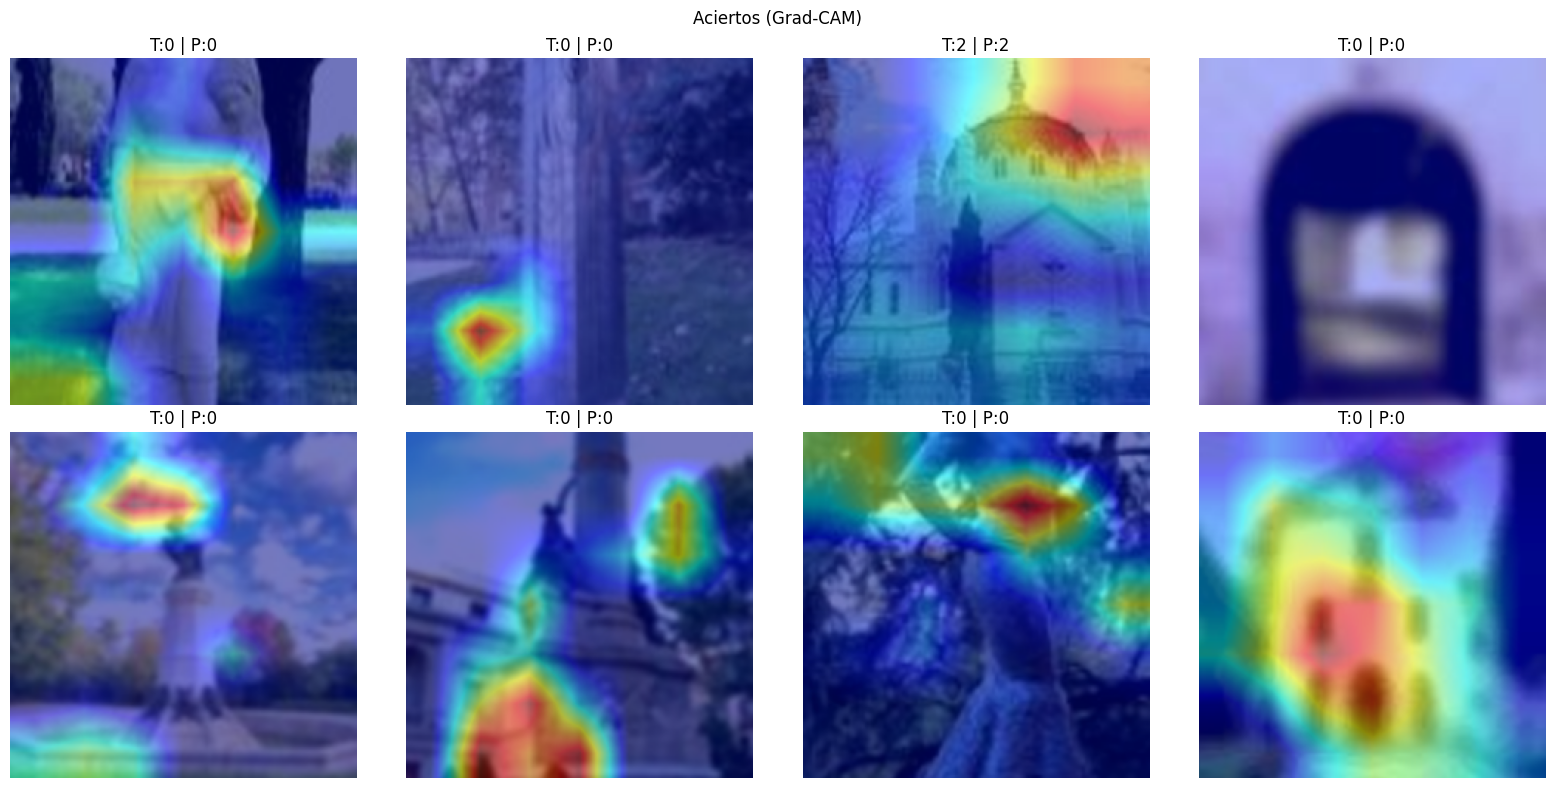

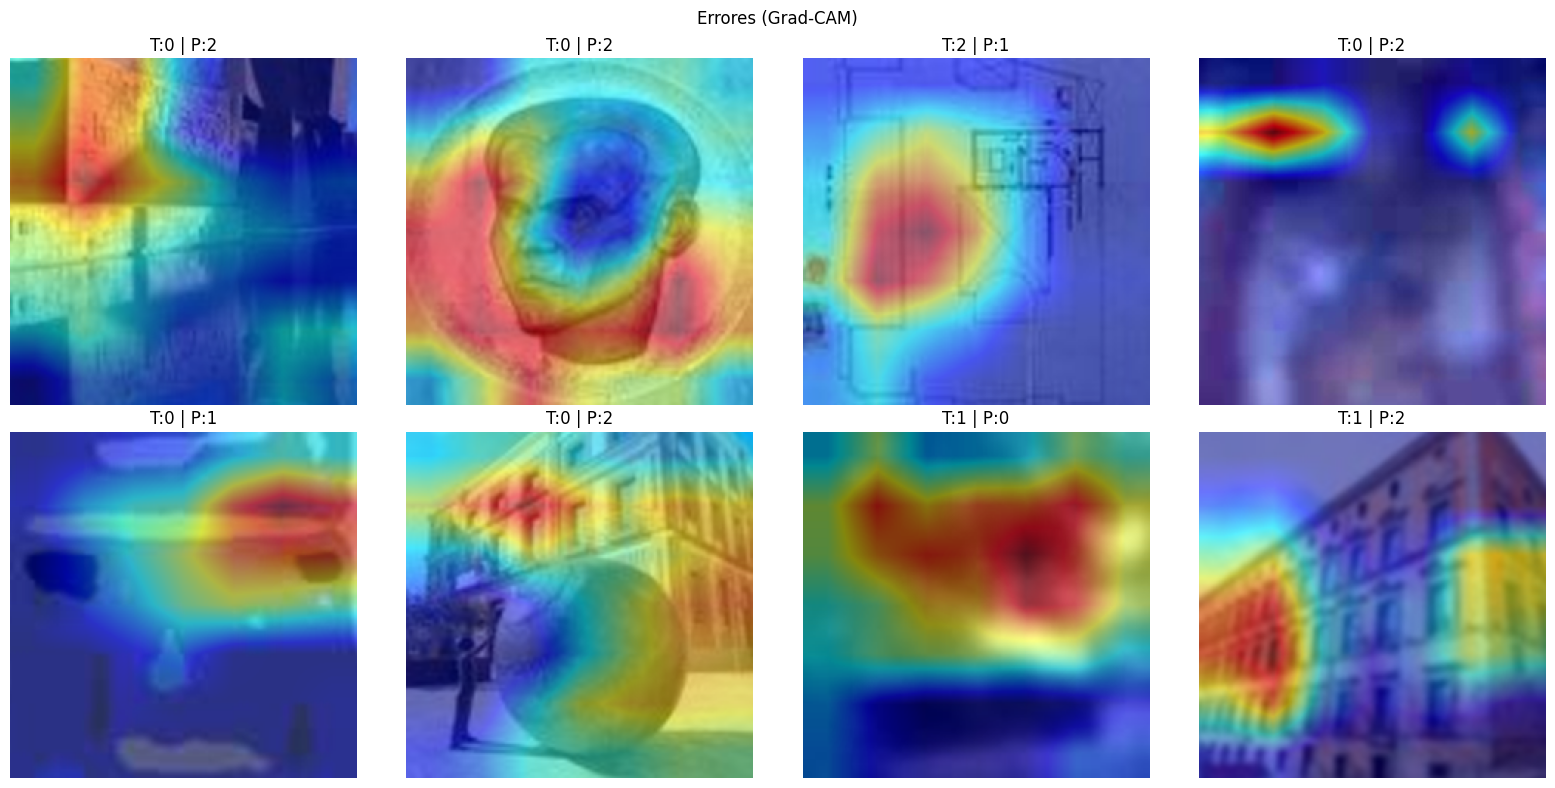

In [62]:
(ok_imgs, ok_lbls, ok_preds, ok_cams), (er_imgs, er_lbls, er_preds, er_cams) = collect_gradcams(
    model_final, test_loader, device, max_ok=8, max_err=8, use_pred_targets=True
)

show_grid(ok_imgs, ok_lbls, ok_preds, ok_cams, title="Aciertos (Grad-CAM)", cols=4)
show_grid(er_imgs, er_lbls, er_preds, er_cams, title="Errores (Grad-CAM)", cols=4)
